setting up the dataset


In [1]:
import numpy as np
import pandas as pd

# For reproducibility
np.random.seed(42)

# Feature names based on the paper
features = [
    "packet_rate",
    "byte_rate",
    "session_duration",
    "error_rate",
    "packet_size_avg",
    "traffic_volume",
    "port_usage_rate",
    "protocol_type",
    "traffic_entropy",
    "signal_strength"
]

print("Number of features:", len(features))

Number of features: 10


In [2]:
def generate_synthetic_network_data(n_samples=1000, contamination=0.1):
    """
    Generate synthetic network traffic data.
    
    Parameters:
    n_samples: total number of samples
    contamination: proportion of anomalous traffic
    
    Returns:
    X: feature dataframe
    y: labels, 0 = normal, 1 = anomaly
    """
    
    n_anomalies = int(n_samples * contamination)
    n_normal = n_samples - n_anomalies
    
    # Normal network traffic
    normal_data = np.random.normal(
        loc=0,
        scale=1,
        size=(n_normal, len(features))
    )
    
    # Anomalous network traffic
    anomalous_data = np.random.normal(
        loc=3,
        scale=1.5,
        size=(n_anomalies, len(features))
    )
    
    # Combine normal and anomalous data
    X = np.vstack([normal_data, anomalous_data])
    y = np.array([0] * n_normal + [1] * n_anomalies)
    
    # Shuffle dataset
    indices = np.random.permutation(n_samples)
    X = X[indices]
    y = y[indices]
    
    # Convert to dataframe
    X = pd.DataFrame(X, columns=features)
    
    return X, y

creating the synthetic network data


In [6]:
X, y = generate_synthetic_network_data(n_samples=1000, contamination=0.1)

df = X.copy()
df["label"] = y

df.head(30)

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,label
0,-1.789272,0.260897,-0.074836,-0.914462,-0.551743,0.109727,-1.493524,-0.603400,-0.263390,-0.299801,0
1,-0.007816,-1.199806,-1.785069,0.842398,0.478674,0.619099,0.879739,-0.899023,-1.876695,0.515855,0
2,0.779773,0.271226,1.366809,0.737181,0.546996,1.327959,0.015405,-0.773100,0.200840,-0.355414,0
3,0.169771,0.840819,1.161607,1.058928,-1.511985,-0.413818,1.171802,0.498136,-0.049429,0.507650,0
4,0.711126,-0.579124,-0.218922,-0.310411,1.286791,0.014320,0.156377,-1.156440,0.730795,0.428107,0
5,-1.578620,0.963871,-1.440121,-0.204249,-1.034891,0.993690,0.582027,-0.357202,0.691184,-1.491739,0
6,-0.519341,0.007283,-0.105708,-0.187792,1.668478,0.305753,-1.570182,1.528420,0.274813,-0.373574,0
7,0.459882,-1.071339,0.017683,0.837841,-0.829857,-0.491880,-1.320059,-0.952519,1.369937,0.504992,0
8,-2.030414,0.214394,-0.771358,0.232510,-1.443619,0.778326,0.037609,-0.344203,-1.694751,1.810535,0
9,-0.171974,-0.939685,0.413996,-0.030579,-0.882978,1.694473,0.057397,-0.416040,-0.253140,1.618668,0


In [4]:
df["label"].value_counts()

label
0    900
1    100
Name: count, dtype: int64

### now we successfully created our artifitial dataset


## The overview of our created dataset :


In [5]:
df.describe()

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.309375,0.337427,0.274206,0.251385,0.317215,0.260763,0.297048,0.308730,0.273393,0.343081,0.10000
std,1.386669,1.423379,1.359391,1.346250,1.415085,1.361988,1.414661,1.432590,1.361561,1.369679,0.30015
min,-3.836656,-3.688365,-3.241267,-2.943142,-3.138515,-3.170426,-2.704392,-3.601085,-3.007632,-3.176704,0.00000
25%,-0.552490,-0.563115,-0.632271,-0.652910,-0.594573,-0.627825,-0.633969,-0.608662,-0.589695,-0.494027,0.00000
50%,0.142342,0.144419,0.087042,0.152056,0.117648,0.164779,0.082891,0.130558,0.139458,0.141002,0.00000
75%,0.956603,1.016425,0.861068,0.885180,0.972823,0.891168,0.997111,0.996195,0.901935,0.899453,0.00000
max,6.006635,6.020331,6.795555,6.257704,6.248282,6.012710,6.053297,6.602375,7.152560,6.081139,1.00000


## It's time to standardize the dataset


In [14]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Standardize the feature data
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Show first rows
X_scaled_df.head()

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength
0,-1.522748,-0.055717,-0.263136,-0.902540,-0.595610,-0.102945,-1.353322,-0.643979,-0.435518,-0.431895
1,-0.233454,-1.113458,-1.463984,0.390868,0.111537,0.273814,0.414004,-0.851069,-1.573099,0.129858
2,0.336548,-0.048238,0.749122,0.313407,0.158424,0.798124,-0.229650,-0.762857,-0.108179,-0.470196
3,-0.104928,0.364222,0.605038,0.550278,-1.254599,-0.490186,0.631499,0.127669,-0.284649,0.124207
4,0.286866,-0.664003,-0.364307,-0.457835,0.666125,-0.173513,-0.124670,-1.031394,0.265505,0.069425


In [15]:
# Show result
X_scaled_df.describe()

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,3.144152e-16,-2.842171e-16,-2.859935e-16,2.655653e-16,-5.151435e-17,-8.171241e-17,3.588241e-16,-2.646772e-16,1.740830e-16,-4.263256e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-3.169474e+00,-3.155011e+00,-2.696892e+00,-2.723007e+00,-2.236065e+00,-2.861306e+00,-2.813443e+00,-2.391598e+00,-2.444515e+00,-2.813211e+00
25%,-6.059543e-01,-6.374976e-01,-6.531987e-01,-6.443249e-01,-6.018288e-01,-6.497185e-01,-6.338049e-01,-6.457649e-01,-6.629949e-01,-6.309683e-01
50%,-1.156097e-01,-8.924424e-02,-1.177968e-01,-1.071388e-01,-1.684939e-01,-1.210011e-01,-9.121079e-02,-1.070699e-01,-1.409614e-01,-9.658830e-02
75%,4.378360e-01,4.354013e-01,4.411897e-01,4.586875e-01,3.983304e-01,4.665752e-01,4.762788e-01,4.620293e-01,4.424820e-01,4.574322e-01
max,5.147944e+00,4.788131e+00,4.635270e+00,4.621804e+00,5.102189e+00,4.413006e+00,4.148029e+00,4.237718e+00,5.470227e+00,4.811610e+00


## Train Isolation Forest Model


In [21]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

model.fit(X_train)


IsolationForest(contamination=0.1, random_state=42)

In [26]:
print("Model training completed.")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Model training completed.
Training samples: 700
Testing samples: 300


In [27]:
# Predict anomalies on the test data
y_pred = model.predict(X_test)

# Show first 20 predictions
print(y_pred[:20])

[ 1  1  1  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1]


In [28]:
# Convert model predictions to binary format
# sklearn: 1 = normal, -1 = anomaly
# our format: 0 = normal, 1 = anomaly

y_pred_binary = np.where(y_pred == -1, 1, 0)

print(y_pred_binary[:20])

[0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0]


In [29]:
unique, counts = np.unique(y_pred_binary, return_counts=True)

prediction_counts = dict(zip(unique, counts))
print(prediction_counts)

{0: 268, 1: 32}


## seeing the result


In [30]:
results_df = X_test.copy()

results_df["true_label"] = y_test
results_df["predicted_label"] = y_pred_binary

results_df.head(20)

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,true_label,predicted_label
480,-0.166318,-1.245385,-0.421835,-0.145456,-0.379728,-1.288251,0.669709,-0.902299,-1.125699,-0.197305,0,0
560,-0.324269,-0.469590,0.394083,-1.292219,0.110615,0.578711,0.312365,-0.271296,-0.251673,0.660056,0,0
362,-0.050700,1.418210,-0.775311,0.902679,0.107053,0.488572,0.012990,1.094485,-0.475490,0.117024,0,0
245,-1.380329,-1.061481,-0.234171,-0.313768,0.010688,0.317830,-0.034093,-0.978833,-0.021319,0.212157,0,0
764,-0.183518,-0.232689,-1.734419,-0.902998,-0.588188,0.149208,-1.471101,-0.586373,-0.707646,-0.145007,0,0
757,-0.474878,-0.266220,-0.242919,-1.191185,-0.601429,0.420116,-1.828640,-0.003177,-0.885451,0.669853,0,0
820,-0.456321,-0.261271,-0.691696,-0.250113,-0.814876,-0.199519,0.844047,0.143409,-0.044568,-1.134340,0,0
410,0.179906,-0.559512,-0.043055,-1.019374,-0.263738,0.555318,0.330159,0.213627,-0.047087,-0.115330,0,0
230,-0.743495,-1.079765,0.058013,0.512610,-0.645823,-0.345177,0.376629,0.427892,-0.086612,0.059848,0,0
549,0.224386,0.577712,-0.833612,-0.206617,-0.903352,0.122285,1.102475,-1.059407,0.235011,0.496794,0,0


### These are the network traffic samples that the Isolation Forest model classified as anomalous.


In [31]:
results_df[results_df["predicted_label"] == 1].head(20)

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,true_label,predicted_label
387,1.847422,-0.163787,3.513266,0.771885,1.916104,2.391874,1.484879,2.137198,1.045585,4.058822,1,1
299,2.834635,2.934843,-0.562410,2.757690,4.184871,2.877408,1.699376,0.708320,0.583815,0.464740,1,1
391,0.758894,3.518610,2.421190,1.440695,0.139466,3.391939,3.405238,1.651766,1.166856,1.572849,1,1
402,4.425932,1.941426,0.890087,2.335666,3.425922,1.129785,1.049463,1.683972,1.182406,0.445852,1,1
44,1.400815,2.691417,2.943965,0.677352,1.155537,1.250252,3.199235,0.645242,2.210055,2.591222,1,1
880,-1.122733,0.726286,1.755775,2.082179,2.195060,2.887039,0.981273,1.922399,1.340640,0.871347,1,1
313,2.984442,0.453975,2.154684,3.192295,1.427411,3.546460,1.308629,2.011370,2.286044,2.620273,1,1
50,0.270686,2.180215,2.648981,1.205004,1.769262,2.240066,0.758353,2.782746,2.089702,2.382541,1,1
48,2.095332,0.289819,1.880602,1.658940,3.129679,0.733540,0.529644,3.478440,1.195922,2.044680,1,1
650,2.086645,-0.209074,3.571021,1.467321,2.303570,0.194040,1.151526,0.307391,0.170113,1.942002,1,1


In [37]:
print("Actual labels in test set:")
print(results_df["true_label"].value_counts())

print("\nPredicted labels by model:")
print(results_df["predicted_label"].value_counts())

Actual labels in test set:
true_label
0    270
1     30
Name: count, dtype: int64

Predicted labels by model:
predicted_label
0    268
1     32
Name: count, dtype: int64


### As seen here the model predicted the anomaly datas with a good percentage


# Evaluation Metrics


In [40]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_binary)*100

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Print results
print("Accuracy:", accuracy , "%")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary, target_names=["Normal", "Anomaly"]))

Accuracy: 99.33333333333333 %

Confusion Matrix:
[[268   2]
 [  0  30]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       270
     Anomaly       0.94      1.00      0.97        30

    accuracy                           0.99       300
   macro avg       0.97      1.00      0.98       300
weighted avg       0.99      0.99      0.99       300



# The Results


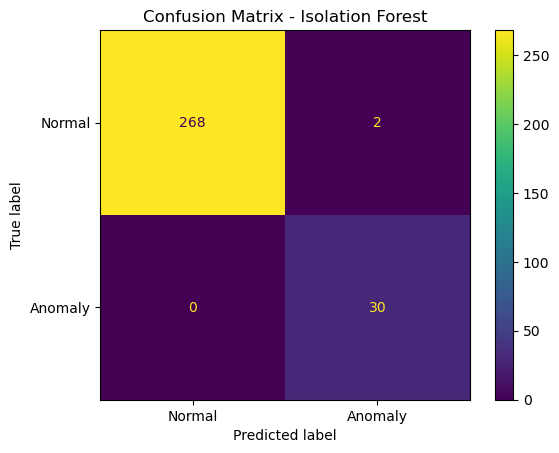

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot()
plt.title("Confusion Matrix - Isolation Forest")
plt.show()

# anomaly score


In [42]:
# Get anomaly scores
# decision_function gives higher scores for normal samples
scores = -model.decision_function(X_test)

print(scores[:10])

[-0.09440131 -0.11412464 -0.10620137 -0.1133417  -0.10316281 -0.07853194
 -0.11210027 -0.12870968 -0.11143019 -0.10369983]


# SDN alert and Policy Changes


In [48]:
# Alert and SDN policy simulation

alert_df = results_df[results_df["predicted_label"] == 1].copy()

total_alerts = len(alert_df)
true_alerts = len(alert_df[alert_df["true_label"] == 1])
false_alerts = len(alert_df[alert_df["true_label"] == 0])

print("Total alerts triggered:", total_alerts)
print("True anomaly alerts:", true_alerts)
print("False positive alerts:", false_alerts)

Total alerts triggered: 32
True anomaly alerts: 30
False positive alerts: 2


In [51]:
# Get anomaly scores
# Higher score means more anomalous
results_df["anomaly_score"] = -model.decision_function(X_test)
# Threshold for stronger policy action
high_risk_threshold = results_df["anomaly_score"].quantile(0.90)

In [52]:
def sdn_policy_action(row):
    if row["predicted_label"] == 0:
        return "No action"
    
    elif row["predicted_label"] == 1 and row["anomaly_score"] >= high_risk_threshold:
        return "Block or rate-limit suspicious flow"
    
    else:
        return "Generate alert and monitor flow"

results_df["sdn_policy_action"] = results_df.apply(sdn_policy_action, axis=1)

In [56]:
policy_summary = results_df["sdn_policy_action"].value_counts()
print(policy_summary)
print("\n")
results_df[results_df["predicted_label"] == 1][
    ["predicted_label", "anomaly_score", "sdn_policy_action"]
].head(20)

sdn_policy_action
No action                              268
Block or rate-limit suspicious flow     30
Generate alert and monitor flow          2
Name: count, dtype: int64




,predicted_label,anomaly_score,sdn_policy_action
387,1,0.064985,Block or rate-limit suspicious flow
299,1,0.127496,Block or rate-limit suspicious flow
391,1,0.083177,Block or rate-limit suspicious flow
402,1,0.088284,Block or rate-limit suspicious flow
44,1,0.052441,Block or rate-limit suspicious flow
880,1,0.053859,Block or rate-limit suspicious flow
313,1,0.084091,Block or rate-limit suspicious flow
50,1,0.041840,Block or rate-limit suspicious flow
48,1,0.065917,Block or rate-limit suspicious flow
650,1,0.020905,Block or rate-limit suspicious flow
